In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
!pip install openpyxl
!pip install statsmodels
!pip install pandas


In [3]:
df1=pd.read_excel('/Users/loksai/Desktop/Credit_risk_modelling/case_study1.xlsx')

In [5]:
df2=pd.read_excel('/Users/loksai/Desktop/Credit_risk_modelling/case_study2.xlsx')

In [6]:
l1=df1
l2=df2

In [7]:
df2.head(10)

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_utilization,CC_Flag,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,549,35,15,11,29,29,0,0,0,-99999,-99999,0,0,21,5,11,0,0,0,0,0,0,0,0,0,29,6,0,0,0,6,0,0,566,0,0,0,Married,12TH,48,M,51000,114,0.200,0.0,0.798,-99999.0,0,0.798,1,0.0,0.0,0.000,0.0,13.333,1,0,PL,PL,696,P2
1,2,47,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,209,1,0,0,Single,GRADUATE,23,F,19000,50,1.000,0.0,0.370,-99999.0,0,-99999.000,0,0.0,0.0,0.000,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,302,11,3,9,25,25,1,9,8,25,25,0,0,10,5,10,0,0,0,0,0,0,0,0,0,25,4,0,0,0,0,0,0,587,0,0,0,Married,SSC,40,M,18,191,1.000,0.5,0.585,-99999.0,0,-99999.000,0,0.0,0.0,0.000,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,-99999,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,5,4,5,0,0,0,0,0,0,0,0,0,0,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,Married,SSC,34,M,10000,246,1.000,1.0,0.990,-99999.0,0,-99999.000,0,0.0,0.0,0.000,0.0,9.900,0,0,others,others,673,P2
4,5,583,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,53,4,16,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,3951,0,0,0,Married,POST-GRADUATE,48,M,15000,75,0.333,0.0,0.000,-99999.0,0,-99999.000,0,0.0,0.0,0.000,0.0,-99999.000,0,0,AL,AL,753,P1
5,6,245,27,18,14,300,270,0,0,0,0,0,13,11,5,0,2,3,0,1,0,0,0,0,0,0,26,15,2,0,1,7,3,3,7,6,5,4,Married,12TH,35,M,0,154,0.167,0.0,0.000,-99999.0,0,-99999.000,0,1.0,0.0,0.429,0.0,-99999.000,1,0,ConsumerLoan,PL,668,P3
6,7,49,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,25,11,20,0,0,0,0,0,0,0,0,0,0,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,Married,SSC,35,M,30000,81,0.667,0.5,0.998,-99999.0,0,-99999.000,0,0.0,0.0,0.000,0.0,-99999.000,1,0,others,others,703,P1
7,8,74,23,12,3,164,133,0,0,0,0,0,2,2,27,0,4,0,0,0,0,0,0,0,0,0,133,2,0,0,0,0,0,0,2,1,1,1,Married,UNDER GRADUATE,30,M,27000,126,0.333,0.0,0.300,-99999.0,0,-99999.000,0,0.0,0.0,0.000,0.0,-99999.000,0,0,ConsumerLoan,others,676,P2
8,9,424,7,4,3,99,38,2,3,1,38,99,3,1,0,0,0,0,0,0,0,0,0,0,0,0,38,3,0,0,0,0,0,0,108,1,1,0,Married,SSC,39,F,18000,122,1.000,0.0,0.465,-99999.0,0,-99999.000,0,0.0,0.0,0.000,0.0,-99999.000,0,0,ConsumerLoan,others,658,P4
9,10,39,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,39,4,10,0,0,0,0,0,0,0,0,0,0,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,Married,12TH,28,M,18000,68,0.500,0.0,1.121,-99999.0,0,-99999.000,0,0.0,0.0,0.000,0.0,3.333,0,0,others,others,705,P1


In [8]:
df1.head(10)

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
0,1,5,4,1,0,0,0.000,0.000,0.200,0.800,0,0,0.000,0.000,0,0,0,0,1,0,4,1,4,0,72,18
1,2,1,0,1,0,0,0.000,0.000,1.000,0.000,1,0,1.000,0.000,0,0,0,1,0,0,0,0,1,0,7,7
2,3,8,0,8,1,0,0.125,0.000,1.000,0.000,2,0,0.250,0.000,1,1,0,6,1,0,0,2,6,0,47,2
3,4,1,0,1,1,0,1.000,0.000,1.000,0.000,1,0,1.000,0.000,1,0,0,0,0,0,0,0,1,1,5,5
4,5,3,2,1,0,0,0.000,0.000,0.333,0.667,0,0,0.000,0.000,0,1,0,0,0,0,0,3,0,2,131,32
5,6,6,5,1,0,0,0.000,0.000,0.167,0.833,0,1,0.000,0.167,0,4,0,0,2,0,0,6,0,0,150,17
6,7,3,1,2,1,1,0.333,0.333,0.667,0.333,2,1,0.667,0.333,1,0,0,0,3,0,0,3,0,0,17,5
7,8,6,4,2,0,0,0.000,0.000,0.333,0.667,1,2,0.167,0.333,0,1,0,0,0,0,0,6,0,5,36,8
8,9,1,0,1,0,0,0.000,0.000,1.000,0.000,0,0,0.000,0.000,0,1,0,0,0,0,0,1,0,0,16,16
9,10,2,1,1,0,0,0.000,0.000,0.500,0.500,0,0,0.000,0.000,0,0,0,0,0,0,0,1,1,2,66,39


In [9]:
df1.shape


(51336, 26)

In [10]:
df2.shape

(51336, 62)

In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PROSPECTID            51336 non-null  int64  
 1   Total_TL              51336 non-null  int64  
 2   Tot_Closed_TL         51336 non-null  int64  
 3   Tot_Active_TL         51336 non-null  int64  
 4   Total_TL_opened_L6M   51336 non-null  int64  
 5   Tot_TL_closed_L6M     51336 non-null  int64  
 6   pct_tl_open_L6M       51336 non-null  float64
 7   pct_tl_closed_L6M     51336 non-null  float64
 8   pct_active_tl         51336 non-null  float64
 9   pct_closed_tl         51336 non-null  float64
 10  Total_TL_opened_L12M  51336 non-null  int64  
 11  Tot_TL_closed_L12M    51336 non-null  int64  
 12  pct_tl_open_L12M      51336 non-null  float64
 13  pct_tl_closed_L12M    51336 non-null  float64
 14  Tot_Missed_Pmnt       51336 non-null  int64  
 15  Auto_TL            

In [12]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 62 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PROSPECTID                    51336 non-null  int64  
 1   time_since_recent_payment     51336 non-null  int64  
 2   time_since_first_deliquency   51336 non-null  int64  
 3   time_since_recent_deliquency  51336 non-null  int64  
 4   num_times_delinquent          51336 non-null  int64  
 5   max_delinquency_level         51336 non-null  int64  
 6   max_recent_level_of_deliq     51336 non-null  int64  
 7   num_deliq_6mts                51336 non-null  int64  
 8   num_deliq_12mts               51336 non-null  int64  
 9   num_deliq_6_12mts             51336 non-null  int64  
 10  max_deliq_6mts                51336 non-null  int64  
 11  max_deliq_12mts               51336 non-null  int64  
 12  num_times_30p_dpd             51336 non-null  int64  
 13  n

In [13]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
PROSPECTID,51336.0,25668.500000,14819.571046,1.0,12834.75,25668.500,38502.250,51336.0
Total_TL,51336.0,4.858598,7.177116,1.0,1.00,2.000,5.000,235.0
Tot_Closed_TL,51336.0,2.770415,5.941680,0.0,0.00,1.000,3.000,216.0
Tot_Active_TL,51336.0,2.088184,2.290774,0.0,1.00,1.000,3.000,47.0
Total_TL_opened_L6M,51336.0,0.736754,1.296717,0.0,0.00,0.000,1.000,27.0
Tot_TL_closed_L6M,51336.0,0.428919,0.989972,0.0,0.00,0.000,1.000,19.0
pct_tl_open_L6M,51336.0,0.184574,0.297414,0.0,0.00,0.000,0.308,1.0
pct_tl_closed_L6M,51336.0,0.089095,0.205635,0.0,0.00,0.000,0.053,1.0
pct_active_tl,51336.0,0.577542,0.379867,0.0,0.25,0.556,1.000,1.0
pct_closed_tl,51336.0,0.422458,0.379867,0.0,0.00,0.444,0.750,1.0


In [14]:
((df1['Age_Oldest_TL']<=-1) | (df1['Age_Oldest_TL']>500)).sum()

np.int64(40)

In [15]:
((df1['Age_Newest_TL']<=-1) | (df1['Age_Newest_TL']>500)).sum()

np.int64(40)

In [16]:
df1=df1[((df1['Age_Newest_TL']>=0) & (df1['Age_Newest_TL']<500))]
df1=df1[((df1['Age_Oldest_TL']>=0) & (df1['Age_Oldest_TL']<500))]
df1.head(10)

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
0,1,5,4,1,0,0,0.000,0.000,0.200,0.800,0,0,0.000,0.000,0,0,0,0,1,0,4,1,4,0,72,18
1,2,1,0,1,0,0,0.000,0.000,1.000,0.000,1,0,1.000,0.000,0,0,0,1,0,0,0,0,1,0,7,7
2,3,8,0,8,1,0,0.125,0.000,1.000,0.000,2,0,0.250,0.000,1,1,0,6,1,0,0,2,6,0,47,2
3,4,1,0,1,1,0,1.000,0.000,1.000,0.000,1,0,1.000,0.000,1,0,0,0,0,0,0,0,1,1,5,5
4,5,3,2,1,0,0,0.000,0.000,0.333,0.667,0,0,0.000,0.000,0,1,0,0,0,0,0,3,0,2,131,32
5,6,6,5,1,0,0,0.000,0.000,0.167,0.833,0,1,0.000,0.167,0,4,0,0,2,0,0,6,0,0,150,17
6,7,3,1,2,1,1,0.333,0.333,0.667,0.333,2,1,0.667,0.333,1,0,0,0,3,0,0,3,0,0,17,5
7,8,6,4,2,0,0,0.000,0.000,0.333,0.667,1,2,0.167,0.333,0,1,0,0,0,0,0,6,0,5,36,8
8,9,1,0,1,0,0,0.000,0.000,1.000,0.000,0,0,0.000,0.000,0,1,0,0,0,0,0,1,0,0,16,16
9,10,2,1,1,0,0,0.000,0.000,0.500,0.500,0,0,0.000,0.000,0,0,0,0,0,0,0,1,1,2,66,39


In [17]:
m=[]
for i in df2.columns:
    if df2[i].dtype!='object':
        m.append(i)

m

['PROSPECTID',
 'time_since_recent_payment',
 'time_since_first_deliquency',
 'time_since_recent_deliquency',
 'num_times_delinquent',
 'max_delinquency_level',
 'max_recent_level_of_deliq',
 'num_deliq_6mts',
 'num_deliq_12mts',
 'num_deliq_6_12mts',
 'max_deliq_6mts',
 'max_deliq_12mts',
 'num_times_30p_dpd',
 'num_times_60p_dpd',
 'num_std',
 'num_std_6mts',
 'num_std_12mts',
 'num_sub',
 'num_sub_6mts',
 'num_sub_12mts',
 'num_dbt',
 'num_dbt_6mts',
 'num_dbt_12mts',
 'num_lss',
 'num_lss_6mts',
 'num_lss_12mts',
 'recent_level_of_deliq',
 'tot_enq',
 'CC_enq',
 'CC_enq_L6m',
 'CC_enq_L12m',
 'PL_enq',
 'PL_enq_L6m',
 'PL_enq_L12m',
 'time_since_recent_enq',
 'enq_L12m',
 'enq_L6m',
 'enq_L3m',
 'AGE',
 'NETMONTHLYINCOME',
 'Time_With_Curr_Empr',
 'pct_of_active_TLs_ever',
 'pct_opened_TLs_L6m_of_L12m',
 'pct_currentBal_all_TL',
 'CC_utilization',
 'CC_Flag',
 'PL_utilization',
 'PL_Flag',
 'pct_PL_enq_L6m_of_L12m',
 'pct_CC_enq_L6m_of_L12m',
 'pct_PL_enq_L6m_of_ever',
 'pct_CC_enq

In [18]:
l=[]
for i in df2.columns:
    if df2[i].dtype=='object':
        l.append(i)
l

['MARITALSTATUS',
 'EDUCATION',
 'GENDER',
 'last_prod_enq2',
 'first_prod_enq2',
 'Approved_Flag']

In [19]:
l=l[0:-1]
for i in l:
    print(df2[i].value_counts())


MARITALSTATUS
Married    37752
Single     13584
Name: count, dtype: int64
EDUCATION
GRADUATE          16673
12TH              14467
SSC                9276
UNDER GRADUATE     5492
OTHERS             2917
POST-GRADUATE      2242
PROFESSIONAL        269
Name: count, dtype: int64
GENDER
M    45245
F     6091
Name: count, dtype: int64
last_prod_enq2
others          20831
ConsumerLoan    17793
PL               7959
CC               2339
AL               1511
HL                903
Name: count, dtype: int64
first_prod_enq2
others          28120
ConsumerLoan    11860
PL               4889
AL               2870
CC               2188
HL               1409
Name: count, dtype: int64


In [20]:
df2[m].describe().T

,count,mean,std,min,25%,50%,75%,max
PROSPECTID,51336.0,25668.500000,14819.571046,1.0,12834.750,25668.500,38502.25000,51336.000
time_since_recent_payment,51336.0,-8129.961314,27749.328514,-99999.0,46.000,70.000,161.00000,6065.000
time_since_first_deliquency,51336.0,-70020.091320,45823.312757,-99999.0,-99999.000,-99999.000,8.00000,35.000
time_since_recent_deliquency,51336.0,-70022.375838,45819.820741,-99999.0,-99999.000,-99999.000,3.00000,35.000
num_times_delinquent,51336.0,1.573749,4.165012,0.0,0.000,0.000,1.00000,74.000
max_delinquency_level,51336.0,-70003.987085,45847.976100,-99999.0,-99999.000,-99999.000,15.00000,900.000
max_recent_level_of_deliq,51336.0,13.521953,53.336976,0.0,0.000,0.000,10.00000,900.000
num_deliq_6mts,51336.0,0.184977,0.710240,0.0,0.000,0.000,0.00000,12.000
num_deliq_12mts,51336.0,0.480053,1.522210,0.0,0.000,0.000,0.00000,28.000
num_deliq_6_12mts,51336.0,0.295076,1.027471,0.0,0.000,0.000,0.00000,20.000


In [21]:
((df2['time_since_first_deliquency']<=-99999) ).sum()

np.int64(35949)

In [22]:
columns_to_be_removed=[]
for i in m:
    if df2.loc[df2[i] < 0].shape[0] > 10000:
        columns_to_be_removed .append(i)
columns_to_be_removed

['time_since_first_deliquency',
 'time_since_recent_deliquency',
 'max_delinquency_level',
 'max_deliq_6mts',
 'max_deliq_12mts',
 'CC_utilization',
 'PL_utilization',
 'max_unsec_exposure_inPct']

In [23]:
df2=df2.drop(columns_to_be_removed,axis=1)
df2.shape

(51336, 54)

In [24]:
for i in df2.columns:
    df2 = df2.loc[ df2[i] != -99999 ]

In [25]:
for i in list(df1.columns):
    if i in list(df2.columns):
        print (i)

PROSPECTID


In [26]:
df=pd.merge(df1,df2,how='inner',right_on='PROSPECTID',left_on='PROSPECTID')

In [27]:
df.shape

(42064, 79)

In [28]:
df['Approved_Flag'].value_counts()

Approved_Flag
P2    25452
P3     6440
P4     5264
P1     4908
Name: count, dtype: int64

In [29]:
df_numeric=[]
for i in df.columns:
    if df[i].dtype!='object':
        df_numeric.append(i)

In [30]:
df[df_numeric].describe()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL,time_since_recent_payment,num_times_delinquent,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,AGE,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,Credit_Score
count,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.00000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.00000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.00000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,4.206400e+04,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000
mean,25649.827477,5.262980,2.967383,2.295597,0.812643,0.48992,0.179032,0.097783,0.577452,0.422548,1.672142,0.825504,0.401271,0.160365,0.525746,0.667626,0.145921,1.362400,1.566304,0.076241,0.328000,2.921334,2.341646,1.116489,46.498074,13.970046,218.601607,1.742939,14.314758,0.21163,0.548593,0.336963,0.773298,0.438879,9.118343,1.464887,3.279978,0.063831,0.002211,0.009224,0.02451,0.001284,0.004279,0.016713,0.001189,0.003376,11.803918,5.457303,0.485641,0.162277,0.268924,1.174971,0.516927,0.779194,264.854507,3.063189,2.002686,1.230458,33.752472,2.692990e+04,110.345783,0.577452,0.309198,0.883693,0.102962,0.193063,0.219169,0.074833,0.195497,0.064186,0.252235,0.056580,679.326336
std,14844.173396,7.463383,6.141098,2.404086,1.383559,1.05892,0.278043,0.210957,0.366110,0.366110,2.249543,1.537208,0.381266,0.258831,1.106442,0.952677,0.549314,2.394966,5.500184,0.358582,0.916368,6.379764,3.405397,2.486801,42.109230,18.835191,422.282417,4.390599,54.056303,0.75794,1.625512,1.097356,2.860464,2.148400,21.514144,3.375811,7.566312,0.799989,0.081704,0.220786,0.62189,0.072637,0.184461,0.573762,0.083310,0.204293,46.422091,6.308943,1.710479,0.681683,1.019459,2.380981,1.373240,1.802092,466.585002,4.299207,3.165782,2.069461,8.774652,2.084300e+04,75.629967,0.366110,0.400555,40.622275,0.303913,0.394707,0.395100,0.250658,0.367414,0.225989,0.434300,0.231042,21.133619
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4

In [31]:
#chi-square test
for i in l:
    chi,p,_,_,=chi2_contingency(pd.crosstab(df[i],df['Approved_Flag']))
    print(i)
    print(" ")
    print(p)


MARITALSTATUS
 
3.5781808610388605e-233
EDUCATION
 
2.6942265249737532e-30
GENDER
 
1.9079361001865664e-05
last_prod_enq2
 
0.0
first_prod_enq2
 
7.849976105554191e-287


In [32]:
#anova test
from scipy.stats import f_oneway
columns_to_be_kept_numerical=[]
for i in df_numeric[1:]:
    a=list(df[i])
    b=list(df['Approved_Flag'])
    group1=[values for values,group in zip(a,b) if group=='P1']
    group2=[values for values,group in zip(a,b) if group=='P2']
    group3=[values for values,group in zip(a,b) if group=='P3']
    group4=[values for values,group in zip(a,b) if group=='P4']
    anova,p=f_oneway(group1,group2,group3,group4)
    if p <= 0.05:
        columns_to_be_kept_numerical.append(i)
columns_to_be_kept_numerical


['Total_TL',
 'Tot_Closed_TL',
 'Tot_Active_TL',
 'Total_TL_opened_L6M',
 'Tot_TL_closed_L6M',
 'pct_tl_open_L6M',
 'pct_tl_closed_L6M',
 'pct_active_tl',
 'pct_closed_tl',
 'Total_TL_opened_L12M',
 'Tot_TL_closed_L12M',
 'pct_tl_open_L12M',
 'pct_tl_closed_L12M',
 'Tot_Missed_Pmnt',
 'Auto_TL',
 'CC_TL',
 'Consumer_TL',
 'Gold_TL',
 'Home_TL',
 'PL_TL',
 'Secured_TL',
 'Unsecured_TL',
 'Other_TL',
 'Age_Oldest_TL',
 'Age_Newest_TL',
 'time_since_recent_payment',
 'num_times_delinquent',
 'max_recent_level_of_deliq',
 'num_deliq_6mts',
 'num_deliq_12mts',
 'num_deliq_6_12mts',
 'num_times_30p_dpd',
 'num_times_60p_dpd',
 'num_std',
 'num_std_6mts',
 'num_std_12mts',
 'num_sub',
 'num_sub_6mts',
 'num_sub_12mts',
 'num_dbt',
 'num_dbt_6mts',
 'num_dbt_12mts',
 'num_lss',
 'recent_level_of_deliq',
 'tot_enq',
 'CC_enq',
 'CC_enq_L6m',
 'CC_enq_L12m',
 'PL_enq',
 'PL_enq_L6m',
 'PL_enq_L12m',
 'time_since_recent_enq',
 'enq_L12m',
 'enq_L6m',
 'enq_L3m',
 'AGE',
 'NETMONTHLYINCOME',
 'Tim

In [33]:
df=df[df_numeric+l+['Approved_Flag']]

In [34]:
#vif
columns_to_be_kept_numerical
vif_columns=[]
for i in df_numeric:
    if i not in['PROSPECTID']:
       vif_columns.append(i)
vif_columns
columns_to_be_kept=[]
vif_data=df[vif_columns]
count=0
for i in range(len(vif_columns)):
    vif=variance_inflation_factor(vif_data,count)
    print(i," ",vif)
    if vif<=7:
        columns_to_be_kept.append(vif_columns[i])
        count+=1
    else:
        vif_data = vif_data.drop([ vif_columns[i] ] , axis=1)
    


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


0   inf


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


1   inf
2   11.320180023967996
3   8.363698035000336
4   6.520647877790928
5   5.150250070949799
6   4.192749257554397


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


7   inf
8   1788.7979988613035
9   8.671796516048735
10   9.52289318957782
11   6.100601860853017
12   4.67350485548511
13   1.9840272494480857


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


14   inf
15   4.814461590116948
16   23.245124501308243
17   30.364135054303894
18   4.383332435945329
19   3.0586362042384923
20   2.70717094021009
21   4.286870961733464
22   2.21097304751535
23   4.971990722259677
24   5.724385597089361
25   3.4442068318266714
26   7.845828006528437
27   5.2547875239132305


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


28   inf
29   7.3814319359516265
30   1.4252058241568046
31   8.084622453288066
32   1.6257280604659226
33   7.2747279158497475
34   15.612404690885011
35   1.8209368346204933
36   1.5075767620544465
37   2.1720977579433667
38   2.6236285062884854
39   2.296000794471227
40   7.360782878273065
41   2.16022777204241
42   2.8688613274326857
43   6.458222026684752
44   8.063589878176996
45   4.7537372474289485
46   16.803527357965095
47   6.435006088547401
48   8.976205951891533
49   5.509845217771625
50   8.923907227153109
51   13.102857387080636
52   3.522144178186199
53   1.9136298957506483
54   18.400550274572467
55   10.742476398258477
56   2.354277248103623
57   22.111346885855603
58   2.7983602833767462
59   3.4249222191636703
60   10.892452714562308
61   6.91870128127444
62   1.001220830480321
63   3.1646892392690247
64   2.812919119028084
65   20.492672383761708
66   17.84430852490961
67   1.836549095810239
68   1.6226873040204048
69   1.965583918767615
70   4.33218969396298
71   

In [35]:
len(df_numeric)
(columns_to_be_kept)

['Tot_TL_closed_L6M',
 'pct_tl_open_L6M',
 'pct_tl_closed_L6M',
 'pct_tl_open_L12M',
 'pct_tl_closed_L12M',
 'Tot_Missed_Pmnt',
 'CC_TL',
 'Home_TL',
 'PL_TL',
 'Secured_TL',
 'Unsecured_TL',
 'Other_TL',
 'Age_Oldest_TL',
 'Age_Newest_TL',
 'time_since_recent_payment',
 'max_recent_level_of_deliq',
 'num_deliq_6_12mts',
 'num_times_60p_dpd',
 'num_std_12mts',
 'num_sub',
 'num_sub_6mts',
 'num_sub_12mts',
 'num_dbt',
 'num_dbt_12mts',
 'num_lss',
 'num_lss_6mts',
 'recent_level_of_deliq',
 'CC_enq',
 'CC_enq_L12m',
 'PL_enq_L12m',
 'time_since_recent_enq',
 'enq_L3m',
 'NETMONTHLYINCOME',
 'Time_With_Curr_Empr',
 'pct_opened_TLs_L6m_of_L12m',
 'pct_currentBal_all_TL',
 'CC_Flag',
 'PL_Flag',
 'pct_PL_enq_L6m_of_ever',
 'pct_CC_enq_L6m_of_ever',
 'HL_Flag',
 'GL_Flag']

In [36]:
df=df[columns_to_be_kept+l+['Approved_Flag','Credit_Score']]

In [37]:

df.shape

(42064, 49)

In [38]:

df['EDUCATION'].value_counts()

EDUCATION
GRADUATE          14140
12TH              11703
SSC                7241
UNDER GRADUATE     4572
OTHERS             2291
POST-GRADUATE      1898
PROFESSIONAL        219
Name: count, dtype: int64

In [39]:
# SSC            : 1
# 12TH           : 2
# GRADUATE       : 3
# UNDER GRADUATE : 3
# POST-GRADUATE  : 4
# OTHERS         : 1
# PROFESSIONAL   : 3
df.loc[df['EDUCATION']=='SSC',['EDUCATION']]=1
df.loc[df['EDUCATION']=='12TH',['EDUCATION']]=2
df.loc[df['EDUCATION']=='GRADUATE',['EDUCATION']]=3
df.loc[df['EDUCATION']=='UNDER GRADUATE',['EDUCATION']]=3
df.loc[df['EDUCATION']=='POST-GRADUATE',['EDUCATION']]=4
df.loc[df['EDUCATION']=='OTHERS',['EDUCATION']]=1
df.loc[df['EDUCATION']=='PROFESSIONAL',['EDUCATION']]=3

    

In [40]:
df['EDUCATION'].value_counts()
df['EDUCATION'] = df['EDUCATION'].astype(int)
df.shape

(42064, 49)

In [41]:
df_encoded=pd.get_dummies(df, columns=['MARITALSTATUS','GENDER', 'last_prod_enq2' ,'first_prod_enq2'])

In [42]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42064 entries, 0 to 42063
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Tot_TL_closed_L6M             42064 non-null  int64  
 1   pct_tl_open_L6M               42064 non-null  float64
 2   pct_tl_closed_L6M             42064 non-null  float64
 3   pct_tl_open_L12M              42064 non-null  float64
 4   pct_tl_closed_L12M            42064 non-null  float64
 5   Tot_Missed_Pmnt               42064 non-null  int64  
 6   CC_TL                         42064 non-null  int64  
 7   Home_TL                       42064 non-null  int64  
 8   PL_TL                         42064 non-null  int64  
 9   Secured_TL                    42064 non-null  int64  
 10  Unsecured_TL                  42064 non-null  int64  
 11  Other_TL                      42064 non-null  int64  
 12  Age_Oldest_TL                 42064 non-null  int64  
 13  A

In [43]:
y = df_encoded['Approved_Flag']
x = df_encoded. drop ( ['Approved_Flag'], axis = 1 )

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
x_train,x_text,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=3)

In [46]:
#random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_recall_fscore_support,classification_report

In [47]:
rf_classifier = RandomForestClassifier(n_estimators = 200, random_state=4)
rf_classifier.fit(x_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
y_cap=rf_classifier.predict(x_text)

In [49]:
accuracy = accuracy_score(y_test, y_cap)
print ()
print(f'Accuracy: {accuracy}')
print ()
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_cap)


Accuracy: 0.9891834066325924



In [50]:
for i, v in enumerate(['p1', 'p2', 'p3', 'p4']):
    print(f"Class {v}:")
    print(f"Precision: {precision[i]}")
    print(f"Recall: {recall[i]}")
    print(f"F1 Score: {f1_score[i]}")
    print()
    

Class p1:
Precision: 0.9324975891996142
Recall: 0.9907786885245902
F1 Score: 0.9607550919026329

Class p2:
Precision: 0.9980349774022401
Recall: 1.0
F1 Score: 0.9990165224232888

Class p3:
Precision: 0.99185667752443
Recall: 0.938366718027735
F1 Score: 0.9643705463182898

Class p4:
Precision: 0.9990557129367328
Recall: 0.9981132075471698
F1 Score: 0.9985842378480415



In [51]:
# 3. Decision Tree
from sklearn.tree import DecisionTreeClassifier


y = df_encoded['Approved_Flag']
x = df_encoded. drop ( ['Approved_Flag'], axis = 1 )

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


dt_model = DecisionTreeClassifier(max_depth=20, min_samples_split=10)
dt_model.fit(x_train, y_train)
y_pred = dt_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print ()
print(f"Accuracy: {accuracy:.2f}")
print ()

precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred)

for i, v in enumerate(['p1', 'p2', 'p3', 'p4']):
    print(f"Class {v}:")
    print(f"Precision: {precision[i]}")
    print(f"Recall: {recall[i]}")
    print(f"F1 Score: {f1_score[i]}")
    print()



Accuracy: 0.99

Class p1:
Precision: 0.9751737835153923
Recall: 0.9684418145956607
F1 Score: 0.9717961405244928

Class p2:
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Class p3:
Precision: 0.975975975975976
Recall: 0.9811320754716981
F1 Score: 0.9785472337222432

Class p4:
Precision: 1.0
Recall: 1.0
F1 Score: 1.0



In [52]:
!pip install xgboost
import xgboost as xgb

In [53]:
#xgboost
y = df_encoded['Approved_Flag']
x = df_encoded. drop ( ['Approved_Flag'], axis = 1 )




In [54]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

In [55]:
label=LabelEncoder()

In [56]:
y_encoded=label.fit_transform(y)

In [57]:
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42)

In [58]:
from xgboost import XGBClassifier

In [59]:
xgboost=XGBClassifier(objective='multi:softmax',num_class=4)

In [60]:
xgboost.fit(x_train,y_train)


,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [61]:
y_pred=xgboost.predict(x_test)

In [62]:
accuracy = accuracy_score(y_test, y_pred)
print ()
print(f"Accuracy: {accuracy:.2f}")
print ()

precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred)

for i, v in enumerate(['p1', 'p2', 'p3', 'p4']):
    print(f"Class {v}:")
    print(f"Precision: {precision[i]}")
    print(f"Recall: {recall[i]}")
    print(f"F1 Score: {f1_score[i]}")
    print()



Accuracy: 0.99

Class p1:
Precision: 0.9857723577235772
Recall: 0.9566074950690335
F1 Score: 0.970970970970971

Class p2:
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Class p3:
Precision: 0.9675276752767528
Recall: 0.9894339622641509
F1 Score: 0.9783582089552239

Class p4:
Precision: 1.0
Recall: 1.0
F1 Score: 1.0



In [ ]:
#xgboost highest
#hyper paremeter tuning
param_grid = {
    'colsample_bytree': [ 0.5, 0.7, 0.9],
    'n_estimators':[50,100,200],
    'max_depth':[3,5,7,9],
    'learning_rate':[0.1,0.2,0.3],
    'alpha'       : [1,10,20],
}

In [ ]:
xg_boost=XGBClassifier(objective='multi:softmax',num_class=4)
grid=GridSearchCV(
    estimator=xg_boost,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(x_train, y_train)

In [74]:
grid.best_params_
grid.best_score_
best=grid.best_estimator_


In [ ]:
index = 0

answers_grid = {
    'combination': [],
    'train_Accuracy': [],
    'test_Accuracy': [],
    'colsample_bytree': [],
    'learning_rate': [],
    'max_depth': [],
    'alpha': [],
    'n_estimators': []
}

for colsample_bytree in param_grid['colsample_bytree']:
    for learning_rate in param_grid['learning_rate']:
        for max_depth in param_grid['max_depth']:
            for alpha in param_grid['alpha']:
                for n_estimators in param_grid['n_estimators']:

                    index = index + 1

                    model = xgb.XGBClassifier(
                        objective='multi:softmax',
                        num_class=4,
                        colsample_bytree=colsample_bytree,
                        learning_rate=learning_rate,
                        max_depth=max_depth,
                        alpha=alpha,
                        n_estimators=n_estimators
                    )

                    y = df_encoded['Approved_Flag']
                    x = df_encoded.drop(['Approved_Flag'], axis=1)

                    label_encoder = LabelEncoder()
                    y_encoded = label_encoder.fit_transform(y)

                    x_train, x_test, y_train, y_test = train_test_split(
                        x,
                        y_encoded,
                        test_size=0.2,
                        random_state=42
                    )

                    model.fit(x_train, y_train)

                    y_pred_train = model.predict(x_train)
                    y_pred_test = model.predict(x_test)

                    train_accuracy = accuracy_score(y_train, y_pred_train)
                    test_accuracy = accuracy_score(y_test, y_pred_test)

                    answers_grid['combination'].append(index)
                    answers_grid['train_Accuracy'].append(train_accuracy)
                    answers_grid['test_Accuracy'].append(test_accuracy)
                    answers_grid['colsample_bytree'].append(colsample_bytree)
                    answers_grid['learning_rate'].append(learning_rate)
                    answers_grid['max_depth'].append(max_depth)
                    answers_grid['alpha'].append(alpha)
                    answers_grid['n_estimators'].append(n_estimators)

                    print(f"Combination {index}")
                    print(
                        f"colsample_bytree: {colsample_bytree}, "
                        f"learning_rate: {learning_rate}, "
                        f"max_depth: {max_depth}, "
                        f"alpha: {alpha}, "
                        f"n_estimators: {n_estimators}"
                    )
                    print(f"Train Accuracy: {train_accuracy:.2f}")
                    print(f"Test Accuracy : {test_accuracy:.2f}")
                    print("-" * 30)

In [63]:
xgboost=XGBClassifier(objective='multi:softmax',num_class=4,colsample_bytree= 0.5,
    learning_rate= 0.3,
    max_depth= 3,
    alpha= 10,
    n_estimators= 50)


In [64]:
xgboost.fit(x_train,y_train)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [65]:
y_pred=xgboost.predict(x_test)

In [66]:
accuracy = accuracy_score(y_test, y_pred)
print ()
print(f"Accuracy: {accuracy:.2f}")
print ()

precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred)

for i, v in enumerate(['p1', 'p2', 'p3', 'p4']):
    print(f"Class {v}:")
    print(f"Precision: {precision[i]}")
    print(f"Recall: {recall[i]}")
    print(f"F1 Score: {f1_score[i]}")
    print()


Accuracy: 0.99

Class p1:
Precision: 0.9989680082559339
Recall: 0.9546351084812623
F1 Score: 0.9762985375693394

Class p2:
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Class p3:
Precision: 0.9664233576642336
Recall: 0.999245283018868
F1 Score: 0.9825602968460111

Class p4:
Precision: 1.0
Recall: 1.0
F1 Score: 1.0



In [68]:
x_train.columns.T

Index(['Tot_TL_closed_L6M', 'pct_tl_open_L6M', 'pct_tl_closed_L6M',
       'pct_tl_open_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'CC_TL',
       'Home_TL', 'PL_TL', 'Secured_TL', 'Unsecured_TL', 'Other_TL',
       'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment',
       'max_recent_level_of_deliq', 'num_deliq_6_12mts', 'num_times_60p_dpd',
       'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt',
       'num_dbt_12mts', 'num_lss', 'num_lss_6mts', 'recent_level_of_deliq',
       'CC_enq', 'CC_enq_L12m', 'PL_enq_L12m', 'time_since_recent_enq',
       'enq_L3m', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr',
       'pct_opened_TLs_L6m_of_L12m', 'pct_currentBal_all_TL', 'CC_Flag',
       'PL_Flag', 'pct_PL_enq_L6m_of_ever', 'pct_CC_enq_L6m_of_ever',
       'HL_Flag', 'GL_Flag', 'EDUCATION', 'Credit_Score',
       'MARITALSTATUS_Married', 'MARITALSTATUS_Single', 'GENDER_F', 'GENDER_M',
       'last_prod_enq2_AL', 'last_prod_enq2_CC', 'last_prod_enq2_Cons

In [69]:
df_encoded['Approved_Flag'].value_counts()

Approved_Flag
P2    25452
P3     6440
P4     5264
P1     4908
Name: count, dtype: int64

In [70]:
import pandas as pd


importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': xgboost.feature_importances_
})

importance.sort_values(
    'importance',
    ascending=False
).head(20)

,feature,importance
43,Credit_Score,0.573421
50,last_prod_enq2_ConsumerLoan,0.068608
12,Age_Oldest_TL,0.068117
31,enq_L3m,0.046101
26,recent_level_of_deliq,0.043431
30,time_since_recent_enq,0.038128
29,PL_enq_L12m,0.035632
15,max_recent_level_of_deliq,0.027307
38,pct_PL_enq_L6m_of_ever,0.027174
18,num_std_12mts,0.026618


In [71]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98      1014
           1       1.00      1.00      1.00      5045
           2       0.97      1.00      0.98      1325
           3       1.00      1.00      1.00      1029

    accuracy                           0.99      8413
   macro avg       0.99      0.99      0.99      8413
weighted avg       0.99      0.99      0.99      8413



In [75]:
import flask

In [77]:
!pip install shap

In [72]:
import shap

In [73]:

explainer = shap.TreeExplainer(xgboost)
shap_values = explainer.shap_values(x_test)

In [79]:
y_pred_proba = xgboost.predict_proba(x_test)

from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(roc_auc)

0.99985995702772


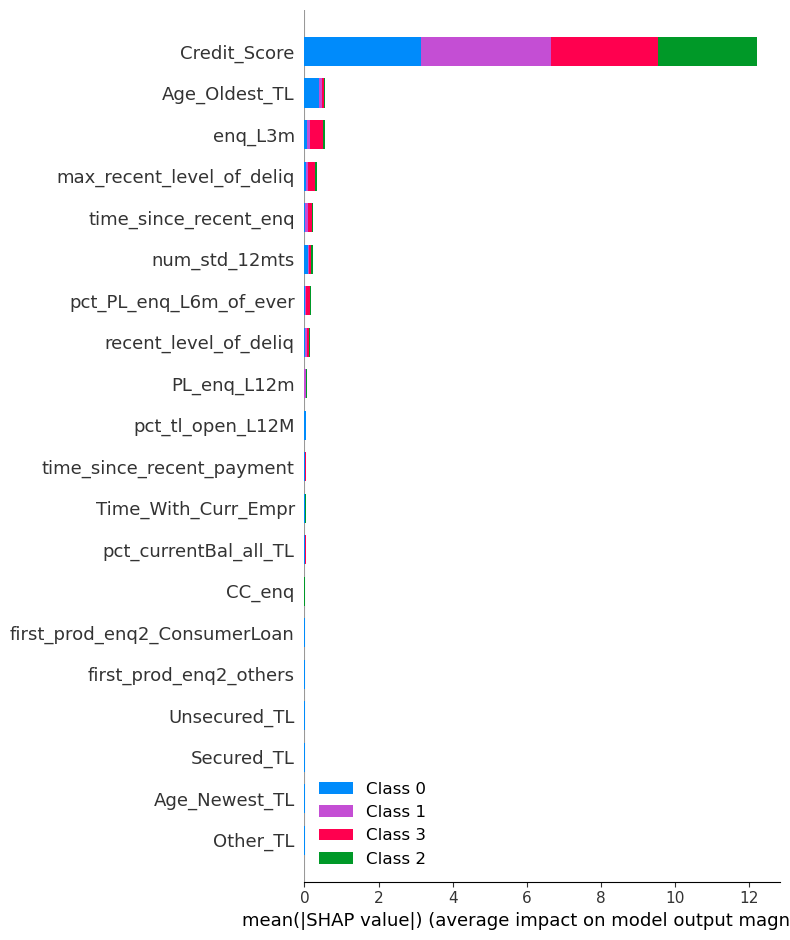

In [74]:
shap.summary_plot(
    shap_values,
    x_test,
    plot_type="bar"
)

In [75]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    x_test.iloc[0]
)

TypeError: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).

In [85]:
import numpy as np

print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(8413, 59, 4)


In [88]:
shap.plots.force(
    explainer.expected_value[0],
    shap_values[0,:,0],
    x_test.iloc[0]
)

In [87]:
import shap

shap.initjs()

In [91]:
import pandas as pd

shap_df = pd.DataFrame({
    'Feature': x_test.columns,
    'SHAP_Value': shap_values[0,:,2]
})

shap_df = shap_df.sort_values(
    'SHAP_Value',
    key=abs,
    ascending=False
)

print(shap_df.head(10))

                      Feature  SHAP_Value
12              Age_Oldest_TL    0.226246
38     pct_PL_enq_L6m_of_ever    0.222088
15  max_recent_level_of_deliq   -0.199759
30      time_since_recent_enq    0.178498
26      recent_level_of_deliq   -0.069316
3            pct_tl_open_L12M   -0.060557
9                  Secured_TL   -0.047413
40                    HL_Flag   -0.036705
29                PL_enq_L12m    0.035973
18              num_std_12mts    0.028103
